# 0.8 — Consumer Base Analysis: Spend Patterns & Recurring Customers

Three questions: do customers spend a lot in one go, or a little across many orders? Do we have recurring customers? And how concentrated is revenue across the customer base — what share of customers drives half the business, and what share of the business comes from half the customers?

**Spend metric**: `Order Item Total` (net of discount — the actual amount charged), not `Sales` (list price). This is a deliberate switch from [`0.1_company_growth.ipynb`](0.1_company_growth.ipynb), which used gross `Sales` for top-line growth; here the question is what customers actually paid.

**Analysis window**: this notebook restricts every customer-level metric to **Jan 2015 – Sep 2017**. §2 shows why the Nov 2017+ data break (already flagged in [`0.1`](0.1_company_growth.ipynb) and `TO_INVESTIGATE.TXT`) isn't just a revenue artifact — it mints a wave of customer IDs that exist for exactly one order and never repeat, which would badly distort a "how many customers are recurring" question if left in.

## 1. Load & prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def dollars(v, _):
    return f'${v:,.0f}'

DATA_DIR = '.'

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['month'] = df['order date (DateOrders)'].dt.to_period('M')

print(f"{df.shape[0]:,} order lines, {df['Order Customer Id'].nunique():,} distinct customer IDs, {df['Order Id'].nunique():,} distinct orders")

180,519 order lines, 20,652 distinct customer IDs, 65,752 distinct orders


## 2. Why this notebook cuts off at Sep 2017

In [3]:
CUTOFF = pd.Timestamp('2017-10-01')
pre_ids = set(df.loc[df['order date (DateOrders)'] < CUTOFF, 'Order Customer Id'])
post_ids = set(df.loc[df['order date (DateOrders)'] >= CUTOFF, 'Order Customer Id'])
post_only = post_ids - pre_ids

post_only_orders = df[df['Order Customer Id'].isin(post_only)].groupby('Order Customer Id')['Order Id'].nunique()

print(f"customer IDs active before Oct 2017: {len(pre_ids):,}")
print(f"customer IDs active Oct 2017 or later: {len(post_ids):,}")
print(f"customer IDs that appear ONLY from Oct 2017 on: {len(post_only):,}")
print(f"of those, share with exactly 1 lifetime order: {(post_only_orders == 1).mean() * 100:.1f}%")

customer IDs active before Oct 2017: 12,330
customer IDs active Oct 2017 or later: 8,403
customer IDs that appear ONLY from Oct 2017 on: 8,322
of those, share with exactly 1 lifetime order: 100.0%


**8,322 of the dataset's 20,652 customer IDs — 40% of the entire customer base — exist only inside the Nov 2017+ artifact window, and every single one of them has exactly one order, ever.** That's not a customer behavior pattern; it's the same data-generation break `0.1` found in order composition (orders collapsing to one line item each), now visible one level up in customer identity. Counting these as "one-time customers" would answer the recurring-customer question with a data artifact instead of real behavior, so every metric below uses **Jan 2015 – Sep 2017** only — the same window `0.1` and `0.7` already treat as the reliable range.

In [4]:
clean = df[df['order date (DateOrders)'] < CUTOFF].copy()
print(f"{clean.shape[0]:,} order lines -> {clean['Order Customer Id'].nunique():,} customers, {clean['Order Id'].nunique():,} orders")

171,962 order lines -> 12,330 customers, 57,349 orders


## 3. Building the customer-level table

In [5]:
order_level = clean.drop_duplicates('Order Id').set_index('Order Id')
profit_by_cust = order_level.groupby('Order Customer Id')['Order Profit Per Order'].sum()

cust = clean.groupby('Order Customer Id').agg(
    n_orders=('Order Id', 'nunique'),
    total_spend=('Order Item Total', 'sum'),
    n_categories=('Category Name', 'nunique'),
    avg_discount_rate=('Order Item Discount Rate', 'mean'),
    late_risk_rate=('Late_delivery_risk', 'mean'),
    segment=('Customer Segment', lambda s: s.mode()[0]),
    market=('Market', lambda s: s.mode()[0]),
    first_order=('order date (DateOrders)', 'min'),
    last_order=('order date (DateOrders)', 'max'),
).reset_index()
cust['total_profit'] = cust['Order Customer Id'].map(profit_by_cust)
cust['aov'] = cust['total_spend'] / cust['n_orders']
cust['tenure_days'] = (cust['last_order'] - cust['first_order']).dt.days

print(f"{len(cust):,} customers")
cust[['n_orders', 'total_spend', 'aov', 'total_profit', 'n_categories', 'tenure_days']].describe().round(1)

12,330 customers


,n_orders,total_spend,aov,total_profit,n_categories,tenure_days
count,12330.0,12330.0,12330.0,12330.0,12330.0,12330.0
mean,4.7,2495.9,536.7,90.3,7.4,588.9
std,2.1,1315.7,162.1,203.6,2.5,261.8
min,1.0,24.2,24.2,-1670.2,1.0,0.0
25%,3.0,1528.2,429.6,15.1,6.0,429.0
50%,4.0,2329.1,532.2,109.0,8.0,645.0
75%,6.0,3298.4,634.1,206.6,9.0,794.0
max,14.0,9436.6,1411.9,832.6,16.0,1002.0


## 4. Big spenders vs. frequent small spenders — is there a tradeoff?

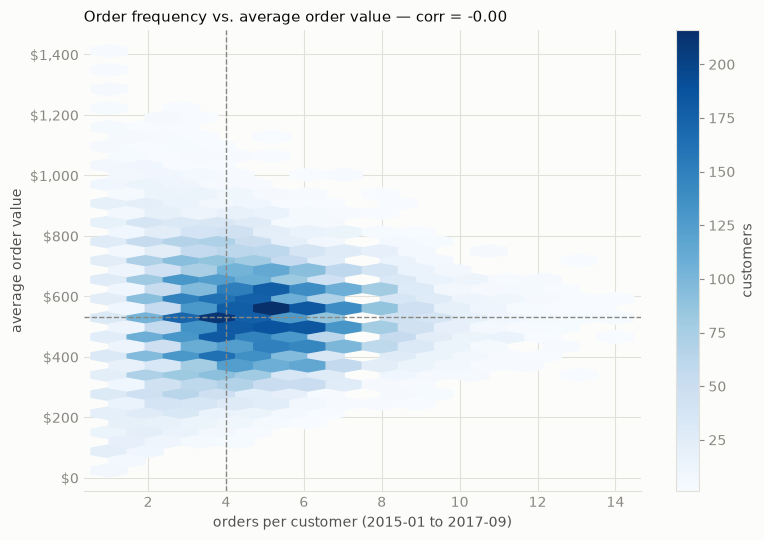

correlation between orders-per-customer and average order value: -0.001


In [6]:
corr = cust['n_orders'].corr(cust['aov'])

fig, ax = plt.subplots(figsize=(8, 5.5))
hb = ax.hexbin(cust['n_orders'], cust['aov'], gridsize=(14, 22), cmap='Blues', mincnt=1)
ax.axhline(cust['aov'].median(), color=INK_MUTED, linewidth=1, linestyle='--', zorder=2)
ax.axvline(cust['n_orders'].median(), color=INK_MUTED, linewidth=1, linestyle='--', zorder=2)
ax.set_xlabel('orders per customer (2015-01 to 2017-09)')
ax.set_ylabel('average order value')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollars))
ax.set_title(f'Order frequency vs. average order value — corr = {corr:.2f}', loc='left', color=INK, fontsize=11)
style_axis(ax)
cb = fig.colorbar(hb, ax=ax, label='customers')
plt.tight_layout()
plt.show()

print(f"correlation between orders-per-customer and average order value: {corr:+.3f}")

Frequency and basket size are essentially **uncorrelated** (r ≈ 0). There's no meaningful population of "big-ticket, once-a-year" shoppers as distinct from "small-basket regulars" — a customer's average order size doesn't predict, and isn't predicted by, how often they come back. The two behaviors that make up total spend (how often, how much per visit) vary independently across the customer base.

In [7]:
med_orders, med_aov = cust['n_orders'].median(), cust['aov'].median()
cust['freq_tier'] = np.where(cust['n_orders'] >= med_orders, 'frequent', 'infrequent')
cust['size_tier'] = np.where(cust['aov'] >= med_aov, 'big basket', 'small basket')

quad = cust.groupby(['freq_tier', 'size_tier']).agg(
    customers=('Order Customer Id', 'size'),
    revenue=('total_spend', 'sum'),
).reset_index()
quad['revenue_share_pct'] = quad['revenue'] / quad['revenue'].sum() * 100
quad['customer_share_pct'] = quad['customers'] / quad['customers'].sum() * 100
quad[['freq_tier', 'size_tier', 'customers', 'customer_share_pct', 'revenue_share_pct']].round(1)

,freq_tier,size_tier,customers,customer_share_pct,revenue_share_pct
0,frequent,big basket,4224,34.3,50.2
1,frequent,small basket,4174,33.9,33.5
2,infrequent,big basket,1941,15.7,10.4
3,infrequent,small basket,1991,16.1,5.8


Median-split into quadrants confirms it: each of the four frequent/infrequent × big/small-basket combinations holds close to a quarter of customers and a quarter of revenue — no single quadrant dominates the business.

## 5. Recurring customers

In [8]:
one_time_pct = (cust['n_orders'] == 1).mean() * 100
print(f"one-time customers (Jan 2015 - Sep 2017 only): {one_time_pct:.1f}%")
print(f"recurring customers (2+ orders): {100 - one_time_pct:.1f}%")
print(f"average orders per customer: {cust['n_orders'].mean():.2f}, median: {cust['n_orders'].median():.0f}")

naive_full = df.groupby('Order Customer Id')['Order Id'].nunique()
naive_one_time_pct = (naive_full == 1).mean() * 100
print(f"\nfor contrast — one-time rate computed on the FULL, uncorrected dataset: {naive_one_time_pct:.1f}%")
print("(inflated almost entirely by the 8,322 artifact-only IDs from §2)")

one-time customers (Jan 2015 - Sep 2017 only): 4.6%
recurring customers (2+ orders): 95.4%
average orders per customer: 4.65, median: 4

for contrast — one-time rate computed on the FULL, uncorrected dataset: 43.0%
(inflated almost entirely by the 8,322 artifact-only IDs from §2)


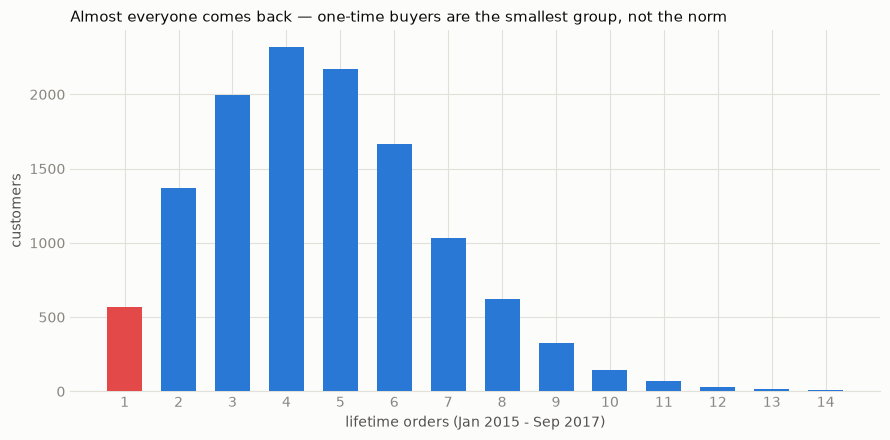

In [9]:
dist = cust['n_orders'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [NEG if n == 1 else BLUE for n in dist.index]
ax.bar(dist.index.astype(str), dist.values, color=colors, width=0.65, zorder=3)
ax.set_xlabel('lifetime orders (Jan 2015 - Sep 2017)')
ax.set_ylabel('customers')
ax.set_title('Almost everyone comes back — one-time buyers are the smallest group, not the norm', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=False)
plt.tight_layout()
plt.show()

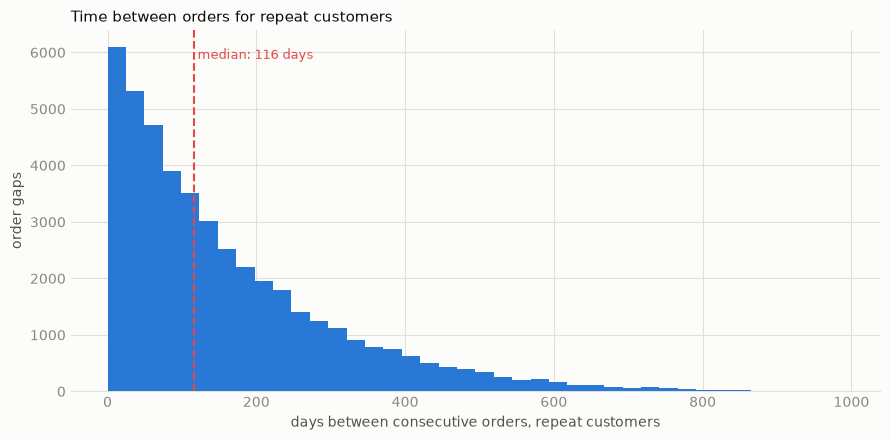

median gap between orders: 116 days, mean: 161 days


In [10]:
order_dates = clean.drop_duplicates('Order Id')[['Order Customer Id', 'order date (DateOrders)']]
repeat_ids = cust.loc[cust['n_orders'] > 1, 'Order Customer Id']
gaps = (order_dates[order_dates['Order Customer Id'].isin(repeat_ids)]
        .sort_values('order date (DateOrders)')
        .groupby('Order Customer Id')['order date (DateOrders)']
        .apply(lambda s: s.diff().dt.days.dropna()))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(gaps, bins=40, color=BLUE, zorder=3)
ax.axvline(gaps.median(), color=NEG, linewidth=1.5, linestyle='--', zorder=4)
ax.text(gaps.median() + 5, ax.get_ylim()[1] * 0.92, f'median: {gaps.median():.0f} days', color=NEG, fontsize=9)
ax.set_xlabel('days between consecutive orders, repeat customers')
ax.set_ylabel('order gaps')
ax.set_title('Time between orders for repeat customers', loc='left', color=INK, fontsize=11)
style_axis(ax)
plt.tight_layout()
plt.show()

print(f"median gap between orders: {gaps.median():.0f} days, mean: {gaps.mean():.0f} days")

**95%+ of customers in the reliable window are recurring** (2 or more orders), averaging roughly one order every 4 months. The 43% "one-time" figure you'd get from the raw, uncorrected file is almost entirely the Nov 2017+ artifact, not a real churn problem — treat any external report that cites that number with suspicion.

## 6. Revenue concentration — two Pareto framings

In [11]:
cs = cust.sort_values('total_spend', ascending=False).reset_index(drop=True)
cs['cum_revenue_pct'] = cs['total_spend'].cumsum() / cs['total_spend'].sum() * 100
cs['cum_customer_pct'] = (cs.index + 1) / len(cs) * 100

n_for_50pct_rev = int((cs['cum_revenue_pct'] >= 50).idxmax() + 1)
pct_custs_for_50pct_rev = n_for_50pct_rev / len(cs) * 100

half_n = len(cs) // 2
rev_share_of_top_half = cs.iloc[:half_n]['total_spend'].sum() / cs['total_spend'].sum() * 100

print(f"{n_for_50pct_rev:,} customers ({pct_custs_for_50pct_rev:.1f}% of the base) generate 50% of revenue")
print(f"the top 50% of customers by spend generate {rev_share_of_top_half:.1f}% of revenue")

3,769 customers (30.6% of the base) generate 50% of revenue
the top 50% of customers by spend generate 70.9% of revenue


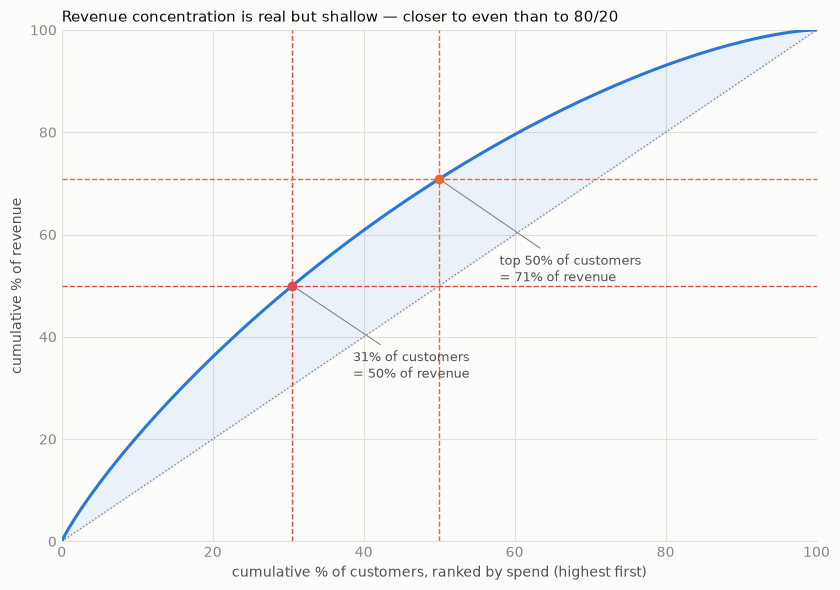

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(cs['cum_customer_pct'], cs['cum_revenue_pct'], color=BLUE, linewidth=2.2, zorder=3)
ax.plot([0, 100], [0, 100], color=INK_MUTED, linewidth=1, linestyle=':', zorder=2, label='perfectly even split')
ax.fill_between(cs['cum_customer_pct'], cs['cum_revenue_pct'], cs['cum_customer_pct'], color=BLUE, alpha=0.08, zorder=1)

ax.axhline(50, color=NEG, linewidth=1, linestyle='--', zorder=2)
ax.axvline(pct_custs_for_50pct_rev, color=NEG, linewidth=1, linestyle='--', zorder=2)
ax.plot([pct_custs_for_50pct_rev], [50], marker='o', color=NEG, zorder=5)
ax.annotate(f'{pct_custs_for_50pct_rev:.0f}% of customers\n= 50% of revenue',
            xy=(pct_custs_for_50pct_rev, 50), xytext=(pct_custs_for_50pct_rev + 8, 32),
            color=INK_SECONDARY, fontsize=9, arrowprops=dict(arrowstyle='-', color=INK_MUTED, lw=0.8))

ax.axvline(50, color=ORANGE, linewidth=1, linestyle='--', zorder=2)
ax.axhline(rev_share_of_top_half, color=ORANGE, linewidth=1, linestyle='--', zorder=2)
ax.plot([50], [rev_share_of_top_half], marker='o', color=ORANGE, zorder=5)
ax.annotate(f'top 50% of customers\n= {rev_share_of_top_half:.0f}% of revenue',
            xy=(50, rev_share_of_top_half), xytext=(58, rev_share_of_top_half - 20),
            color=INK_SECONDARY, fontsize=9, arrowprops=dict(arrowstyle='-', color=INK_MUTED, lw=0.8))

ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel('cumulative % of customers, ranked by spend (highest first)')
ax.set_ylabel('cumulative % of revenue')
ax.set_title('Revenue concentration is real but shallow — closer to even than to 80/20', loc='left', color=INK, fontsize=11)
style_axis(ax)
plt.tight_layout()
plt.show()

Both framings say the same thing: this is **not** an 80/20, whale-driven business. Revenue is spread broadly across the customer base — roughly a third of customers account for half the revenue, and the top half of customers account for about seven-tenths of it, well short of the extreme concentration a classic Pareto pattern would show. That matches §4: since order size and frequency aren't correlated, there's no small cluster of customers who dominate on both axes at once.

## 7. A few more cuts worth having on hand

In [13]:
seg = cust.groupby('segment').agg(customers=('Order Customer Id', 'size'), avg_orders=('n_orders', 'mean'), avg_spend=('total_spend', 'mean'))
seg['revenue_share_pct'] = cust.groupby('segment')['total_spend'].sum() / cust['total_spend'].sum() * 100
seg['customer_share_pct'] = seg['customers'] / seg['customers'].sum() * 100
seg.round(1)

,customers,avg_orders,avg_spend,revenue_share_pct,customer_share_pct
segment,,,,,
Consumer,6409,4.6,2491.3,51.9,52.0
Corporate,3709,4.7,2515.5,30.3,30.1
Home Office,2212,4.6,2476.3,17.8,17.9


`Customer Segment` (Consumer / Corporate / Home Office) tracks revenue share almost exactly to customer share — no segment over- or under-indexes on spend, so segment isn't a useful lens for finding high-value customers on its own.

In [14]:
mkt = cust.groupby('market').agg(customers=('Order Customer Id', 'size'), avg_spend=('total_spend', 'mean'), avg_orders=('n_orders', 'mean'))
mkt['revenue_share_pct'] = cust.groupby('market')['total_spend'].sum() / cust['total_spend'].sum() * 100
mkt['customer_share_pct'] = mkt['customers'] / mkt['customers'].sum() * 100
mkt.sort_values('revenue_share_pct', ascending=False).round(1)

,customers,avg_spend,avg_orders,revenue_share_pct,customer_share_pct
market,,,,,
LATAM,4128,2578.1,4.8,34.6,33.5
Europe,3980,2561.6,4.8,33.1,32.3
Pacific Asia,2161,2468.8,4.6,17.3,17.5
USCA,1357,2299.7,4.3,10.1,11.0
Africa,704,2103.1,3.9,4.8,5.7


correlation between a customer's total spend and their profit MARGIN: -0.075


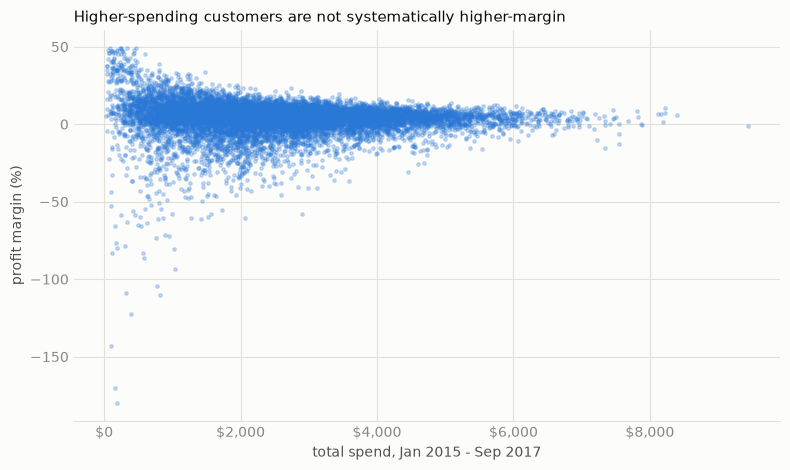

In [15]:
margin_corr = cust['total_spend'].corr(cust['total_profit'] / cust['total_spend'])
print(f"correlation between a customer's total spend and their profit MARGIN: {margin_corr:+.3f}")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(cust['total_spend'], cust['total_profit'] / cust['total_spend'] * 100, s=6, alpha=0.25, color=BLUE, zorder=3)
ax.set_xlabel('total spend, Jan 2015 - Sep 2017')
ax.set_ylabel('profit margin (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollars))
ax.set_title('Higher-spending customers are not systematically higher-margin', loc='left', color=INK, fontsize=11)
style_axis(ax)
plt.tight_layout()
plt.show()

Spend and margin are close to uncorrelated at the customer level — a big spender is not automatically a profitable one. That's worth carrying into §0.8.1: revenue-ranked "top" customers and profit-ranked "best" customers are not guaranteed to be the same people.

## 8. Added value per additional order — marginal LTV by order count

Section 4 found frequency and AOV uncorrelated across the *whole customer population* (r ≈ 0). That's a population-level statement — it doesn't say what happens to a single customer's *own* order sizes as they place more of them, or how much lifetime value each additional order is actually worth. Two direct cuts on that, both restricted to the same Jan 2015 - Sep 2017 window:

1. **Order-sequence AOV** — for each customer, rank their orders 1st, 2nd, 3rd... by date, and compare the average order value at each position. This tests whether *this* customer's basket grows the more times they buy.
2. **Marginal lifetime value** — average total spend for customers who ended up placing exactly N orders, and the step-up from N to N+1. This is the direct answer to "how much value does one more purchase add."

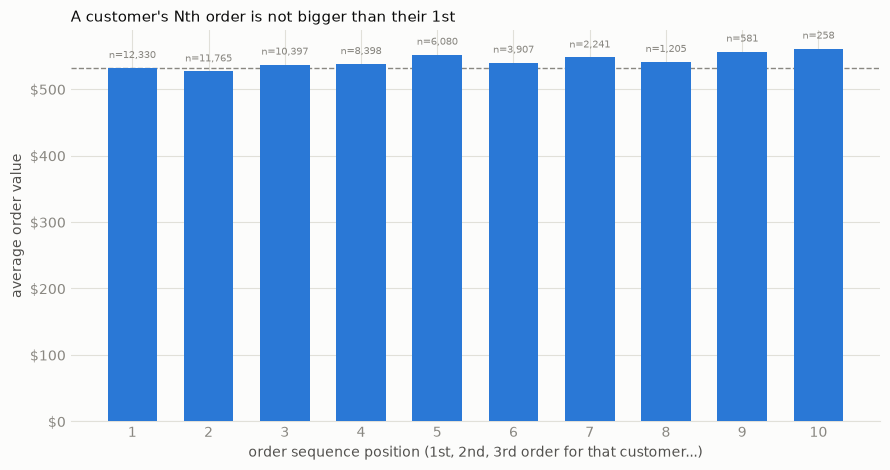

      mean      n
seq              
1    531.9  12330
2    526.8  11765
3    537.0  10397
4    537.9   8398
5    551.9   6080
6    539.9   3907
7    547.7   2241
8    541.1   1205
9    556.7    581
10   561.1    258


In [16]:
# true order-level value: Order Item Total is a LINE-ITEM field (~3 lines/order pre-Oct 2017),
# so it must be summed per Order Id, not taken from one deduped row
order_totals = clean.groupby('Order Id').agg(
    customer=('Order Customer Id', 'first'),
    order_date=('order date (DateOrders)', 'first'),
    order_value=('Order Item Total', 'sum'),
).reset_index()

order_totals = order_totals.sort_values(['customer', 'order_date'])
order_totals['seq'] = order_totals.groupby('customer').cumcount() + 1

MAX_SEQ = 10
pos = order_totals[order_totals['seq'] <= MAX_SEQ].groupby('seq')['order_value'].agg(mean='mean', n='count')

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(pos.index.astype(str), pos['mean'], color=BLUE, width=0.65, zorder=3)
ax.axhline(pos['mean'].iloc[0], color=INK_MUTED, linewidth=1, linestyle='--', zorder=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollars))
ax.set_xlabel('order sequence position (1st, 2nd, 3rd order for that customer...)')
ax.set_ylabel('average order value')
ax.set_title('A customer\'s Nth order is not bigger than their 1st', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=False)
for i, (m, n) in enumerate(zip(pos['mean'], pos['n'])):
    ax.text(i, m + 15, f'n={n:,}', ha='center', fontsize=7.5, color=INK_MUTED)
plt.tight_layout()
plt.show()

print(pos.round(1))

Flat, within noise — average order value sits in a tight \$527-\$561 band from the 1st order through the 10th, no upward (or downward) trend. This confirms section 4's r ≈ 0 finding at the individual-customer level, not just in aggregate: a customer's own basket doesn't grow as they come back — each purchase is drawn from roughly the same distribution.

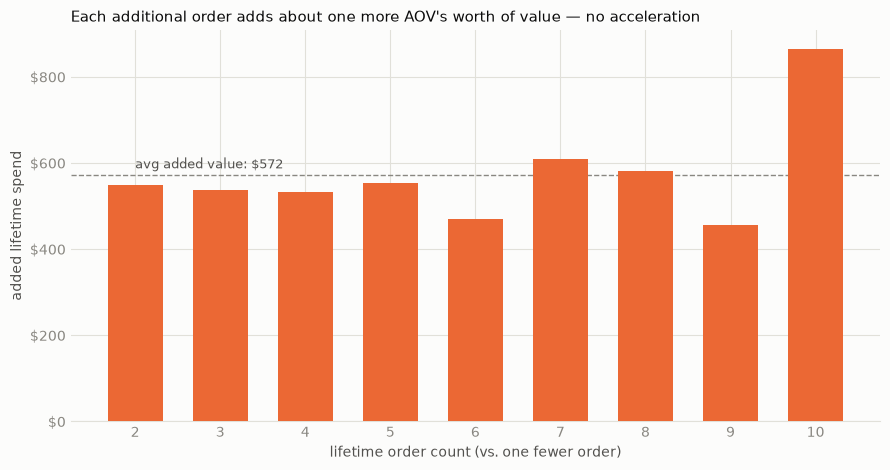

          mean_lifetime_spend  n_customers  added_value_vs_prev_tier
n_orders                                                            
1                       529.3          565                       NaN
2                      1078.3         1368                     549.0
3                      1614.3         1999                     535.9
4                      2146.6         2318                     532.3
5                      2698.9         2173                     552.3
6                      3168.1         1666                     469.3
7                      3777.7         1036                     609.5
8                      4359.8          624                     582.1
9                      4814.7          323                     454.9
10                     5680.0          258                     865.4


In [17]:
# marginal lifetime value: mean total spend by lifetime order count, and the step-up per tier
MAX_TIER = 10  # tier 10 is open-ended (10+ orders)
tiers = cust['n_orders'].clip(upper=MAX_TIER)
marginal = pd.DataFrame({
    'mean_lifetime_spend': cust.groupby(tiers)['total_spend'].mean(),
    'n_customers': cust.groupby(tiers).size(),
})
marginal['added_value_vs_prev_tier'] = marginal['mean_lifetime_spend'].diff()

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_data = marginal['added_value_vs_prev_tier'].dropna()
ax.bar(plot_data.index.astype(str), plot_data.values, color=ORANGE, width=0.65, zorder=3)
ax.axhline(plot_data.mean(), color=INK_MUTED, linewidth=1, linestyle='--', zorder=2)
ax.text(0, plot_data.mean() + 15, f'avg added value: ${plot_data.mean():,.0f}', color=INK_SECONDARY, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollars))
ax.set_xlabel('lifetime order count (vs. one fewer order)')
ax.set_ylabel('added lifetime spend')
ax.set_title('Each additional order adds about one more AOV\'s worth of value — no acceleration', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=False)
plt.tight_layout()
plt.show()

print(marginal.round(1))

**Answer: roughly one more average order's worth (~\$530-\$610) per additional purchase, flat across the whole range — not growing, not shrinking.** The step-up from N to N+1 orders bounces between \$455 and \$865 with no trend (mean ≈ \$570), which is just the AOV band from the sequence chart above with more noise at the higher tiers (fewer customers). There's no compounding — a customer's 8th order doesn't add more value than their 2nd. Lifetime value is **strictly additive**: `LTV ≈ n_orders × AOV`, not `n_orders × (growing AOV)`. This matches the interview-mock `orders.csv` dataset's own finding on this exact question (loyalty premium comes from *frequency*, not basket-size growth) — same conclusion, independently derived from a different dataset, not carried over from it.

## Takeaways
- **Value is additive, not compounding.** A customer's Nth order is no bigger than their 1st (AOV flat \$527-\$561 across the first 10 orders), and each additional lifetime order adds roughly one more AOV's worth of spend (\$530-\$610, no trend) — so `LTV ≈ n_orders × AOV`, not a growing basket. See §8.

- **No big-ticket-vs-frequent-small-basket divide.** Order frequency and average order value are uncorrelated (r ≈ 0.00) — customers don't trade off one for the other.
- **The business is overwhelmingly repeat-purchase.** In the reliable Jan 2015 – Sep 2017 window, 95%+ of customers place 2+ orders, averaging a reorder roughly every 4 months (median 116 days). The commonly-computed "43% one-time" figure is a data artifact, not churn — see §2.
- **The Nov 2017+ data break contaminates customer identity, not just order size.** 8,322 customer IDs (40% of all IDs in the raw file) exist for exactly one order and only after Oct 2017 — almost certainly the same generation fault `0.1` already flagged in order line-item counts.
- **Revenue concentration is real but shallow.** ~31% of customers drive 50% of revenue; the top half of customers drive ~71% of revenue — far from an 80/20 whale-driven pattern.
- **Segment and market track revenue share to customer share almost exactly** — neither is a useful lever for spotting high-value customers by itself.
- **Spend and margin are nearly uncorrelated at the customer level** — flagging this for the top-15% deep dive in [`0.8.1_deepdive_top15pct.ipynb`](0.8.1_deepdive_top15pct.ipynb), since "highest revenue" customers won't automatically be the most profitable ones.